In [1]:
"""
INTEGRATED FIGURE 1: Complete Analysis Pipeline
Fixed version with proper execution order
"""

# %%
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import warnings
from scipy.sparse import csr_matrix
from scipy import stats
from datetime import datetime
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.sparse import issparse

warnings.filterwarnings("ignore")

# Import ATSE coordination functions
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation') 

# Plotting configuration
sns.set_theme(context="notebook", style="white")
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 12,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.0,
    'axes.grid': False,
})


## To-do
- remove unused functions
- make sure junctions and cells are reindexed in .obs and .var so correctly pulled from psi layer 
- coordination, be more careful about getting mean J1 and mean J2, use just non zero values for these calcualtions and record how many
because otherwise mean gets crazy skewed
- go through one sanity check example showing raw data counts and psi values for J1 in young vs J1 in old, partner J2 should show opposite effect

In [2]:
# Setup
today = datetime.now().strftime("%Y%m%d")
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"

# =========================================================================
# PART 1: Load and Preprocess Data
# =========================================================================

print("\n" + "="*60)
print("PART 1: DATA LOADING AND PREPROCESSING")
print("="*60)

SPLICE_INPUT = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/FIGURES/FIGURE1/figure1_20251019/preprocessed_data_20251019.h5ad"
ATSE_FILE_PATH = f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-10-01_21-36-40.txt.gz"

print("Loading data...")
splice_adata = ad.read_h5ad(SPLICE_INPUT)
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
print(f"Loaded {splice_adata.n_obs:,} cells and {splice_adata.n_vars:,} junctions")


PART 1: DATA LOADING AND PREPROCESSING
Loading data...
Loaded 85,692 cells and 52,290 junctions


In [3]:
splice_adata

AnnData object with n_obs × n_vars = 85692 × 52290
    obs: 'cell_id_index', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'broad_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'age_group', 'tissue_celltype'
    var: 'level_0', 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'n_cells_detected', 'confidence', 'aging_gene', 'aging_lifespan_effect', 'aging_longevity_influence'
    obsm: 'X_library_size'
    layers: 'cell_by_cluster_matrix', 'cell_by_junction_matrix', 'psi', 'psi_valid'

In [4]:
splice_adata.layers["psi"]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 329055604 stored elements and shape (85692, 52290)>

In [5]:
splice_adata.layers["cell_by_junction_matrix"]

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 329055604 stored elements and shape (85692, 52290)>

In [6]:
splice_adata.layers["cell_by_cluster_matrix"]

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 329055604 stored elements and shape (85692, 52290)>

In [7]:
def extract_junction_data(adata, junction_ids, cell_type, groupby_col='tissue_celltype'):
    """
    Extract junction counts, ATSE counts, and PSI values for given junctions and cell type.
    
    Parameters:
    -----------
    adata : AnnData
        Annotated data object with junction data
    junction_ids : str or list
        Single junction ID or list of junction IDs to extract
    cell_type : str
        Cell type to filter for (value in groupby_col)
    groupby_col : str, default='tissue_celltype'
        Column name to use for cell type filtering
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns: cell_id, junction_id, junction_counts, atse_counts, psi_value
    """
    from scipy.sparse import issparse
    import pandas as pd
    import numpy as np
    
    # Ensure junction_ids is a list
    if isinstance(junction_ids, str):
        junction_ids = [junction_ids]
    
    # Filter cells for the specified cell type
    if groupby_col not in adata.obs.columns:
        raise ValueError(f"Column '{groupby_col}' not found in adata.obs")
    
    cell_mask = adata.obs[groupby_col] == cell_type
    if not cell_mask.any():
        raise ValueError(f"No cells found for cell type '{cell_type}'")
        
    # Find ATSE that junction belongs to via event_id 
    atse_event_id = adata.var[adata.var["junction_id"].isin(junction_ids)]["event_id"].unique()[0]

    # Find all junctions in this ATSE event
    atse_junctions = adata.var[adata.var['event_id'] == atse_event_id]['junction_id']
    junction_mask = adata.var['junction_id'].isin(atse_junctions)

    # Get the relevant matrices
    junction_matrix = adata.layers["cell_by_junction_matrix"]
    atse_matrix = adata.layers["cell_by_cluster_matrix"] 
    psi_matrix = adata.layers["psi"]
    
    # Extract data for selected cells and junctions
    cell_indices = np.where(cell_mask)[0]
    junction_indices = np.where(junction_mask)[0]
    
    results = []
    
    for cell_idx in cell_indices:
        cell_id = adata.obs.index[cell_idx]
        cell_age_group = adata.obs.loc[cell_id, "age_group"]
        
        for junc_idx in junction_indices:
            # Get junction ID
            if 'junction_id' in adata.var.columns:
                junction_id = adata.var.iloc[junc_idx]['junction_id']
            else:
                junction_id = adata.var.index[junc_idx]
            
            # Extract values (handle sparse matrices)
            if issparse(junction_matrix):
                junction_count = junction_matrix[cell_idx, junc_idx]
                atse_count = atse_matrix[cell_idx, junc_idx]
                psi_value = psi_matrix[cell_idx, junc_idx]
            else:
                junction_count = junction_matrix[cell_idx, junc_idx]
                atse_count = atse_matrix[cell_idx, junc_idx]
                psi_value = psi_matrix[cell_idx, junc_idx]
            
            # Only include non-zero entries (sparse data)
            if junction_count > 0 or atse_count > 0:
                results.append({
                    'cell_id': cell_id,
                    'cell_age_group': cell_age_group,
                    'junction_id': junction_id,
                    'junction_counts': float(junction_count),
                    'atse_counts': float(atse_count),
                    'psi_value': float(psi_value) if not np.isnan(psi_value) else None
                })
    
    df = pd.DataFrame(results)
    
    gene_name = adata.var[adata.var["junction_id"].isin(junction_ids)]["gene_name"].unique()[0]
    df["event_id"] = atse_event_id
    df["cell_type"] = cell_type
    df["gene_name"] = gene_name
    return df

def delta_psi_from_result_df(result_df, young_label="young", old_label="old", cell_type=None):
    """
    Compute per-junction ΔPSI (old - young), pseudobulk per age group,
    and ATSE-level coordination from a tidy `result_df` produced by `extract_junction_data`.

    Required columns in `result_df`:
      ['cell_id','cell_age_gr oup','junction_id','psi_value',
       'junction_counts','atse_counts','event_id']
    Optional: ['gene_name']

    Parameters
    ----------
    result_df : pd.DataFrame
    young_label, old_label : str
        Labels used in `cell_age_group` for young/old.
    cell_type : str or None
        The cell type the `result_df` was filtered to (will be attached to outputs).
        If None, defaults to 'unknown'.

    Returns
    -------
    junction_df : DataFrame with columns
        ['cell_type','junction_id','event_id','gene_name'(opt),
         'n_cells_young','n_cells_old',
         'psi_mean_young','psi_mean_old','delta_psi_mean',
         'psi_median_young','psi_median_old','delta_psi_median',
         'pb_young','pb_old','delta_pb']
    atse_df : DataFrame with columns
        ['cell_type','event_id','n_junctions','mean_delta_mean','median_delta_median',
         'mean_abs_delta','std_delta','sign_concordance','opposite_sign_pair']
    """

    req = {"cell_id","cell_age_group","junction_id","psi_value",
           "junction_counts","atse_counts","event_id"}
    missing = req - set(result_df.columns)
    if missing:
        raise ValueError(f"result_df missing required columns: {sorted(missing)}")

    df = result_df.copy()
    cell_type = result_df["cell_type"].iloc[0]

    # --- Per-junction per-age PSI stats (mean/median, counts) ---
    agg = (df.groupby(["junction_id","cell_age_group"], observed=True)
             .agg(psi_mean=("psi_value","mean"),
                  psi_median=("psi_value","median"),
                  n_cells=("psi_value","count")))
    wide = agg.unstack("cell_age_group")

    def getcol(name, age):
        col = (name, age)
        return wide[col] if col in wide.columns else pd.Series(index=wide.index, dtype=float)

    psi_mean_y = getcol("psi_mean", young_label)
    psi_mean_o = getcol("psi_mean", old_label)
    psi_med_y  = getcol("psi_median", young_label)
    psi_med_o  = getcol("psi_median", old_label)
    n_y        = getcol("n_cells", young_label).astype("Int64")
    n_o        = getcol("n_cells", old_label).astype("Int64")

    d_mean = psi_mean_o - psi_mean_y
    d_med  = psi_med_o  - psi_med_y

    # --- Pseudobulk per junction-age: sum(junc)/sum(atse) ---
    sums = (df.groupby(["junction_id","cell_age_group"], observed=True)
              .agg(junc_sum=("junction_counts","sum"),
                   atse_sum=("atse_counts","sum"))).unstack("cell_age_group")

    def getsum(name, age):
        col = (name, age)
        return sums[col] if col in sums.columns else pd.Series(index=sums.index, dtype=float)

    junc_sum_y = getsum("junc_sum", young_label)
    junc_sum_o = getsum("junc_sum", old_label)
    atse_sum_y = getsum("atse_sum", young_label)
    atse_sum_o = getsum("atse_sum", old_label)

    def safe_div(num, den):
        num = num.astype(float); den = den.astype(float)
        return np.divide(num, den, out=np.full_like(num, np.nan, dtype=float), where=(den > 0))

    pb_y = safe_div(junc_sum_y, atse_sum_y)
    pb_o = safe_div(junc_sum_o, atse_sum_o)
    d_pb = pb_o - pb_y

    # --- Junction-level table (keep junction_id as a normal column) ---
    j_meta = df.drop_duplicates("junction_id").set_index("junction_id")
    junction_df = pd.DataFrame({
        "event_id": j_meta["event_id"],
    })
    if "gene_name" in j_meta.columns:
        junction_df["gene_name"] = j_meta["gene_name"]

    junction_df["n_cells_young"]     = n_y
    junction_df["n_cells_old"]       = n_o
    junction_df["psi_mean_young"]    = psi_mean_y
    junction_df["psi_mean_old"]      = psi_mean_o
    junction_df["delta_psi_mean"]    = d_mean
    junction_df["psi_median_young"]  = psi_med_y
    junction_df["psi_median_old"]    = psi_med_o
    junction_df["delta_psi_median"]  = d_med
    junction_df["pb_young"]          = pb_y
    junction_df["pb_old"]            = pb_o
    junction_df["delta_pb"]          = d_pb

    # move junction_id out of index into a column, and add cell_type
    junction_df = junction_df.reset_index()  # adds 'junction_id' column
    junction_df.insert(0, "cell_type", cell_type)

    # reorder columns exactly as requested (gene_name optional)
    base_cols = [
        "cell_type", "junction_id", "event_id",
        "gene_name" if "gene_name" in junction_df.columns else None,
        "n_cells_young","n_cells_old",
        "psi_mean_young","psi_mean_old","delta_psi_mean",
        "psi_median_young","psi_median_old","delta_psi_median",
        "pb_young","pb_old","delta_pb",
    ]
    junction_df = junction_df[[c for c in base_cols if c is not None]]

    # --- ATSE-level summaries (also tag cell_type) ---
    def sign_concordance(series):
        s = np.sign(series.to_numpy(dtype=float))
        nz = s[s != 0]
        if nz.size == 0:
            return np.nan
        p_pos = (nz > 0).mean()
        return max(p_pos, 1.0 - p_pos)

    def opposite_sign_pair(series):
        s = np.sign(series.to_numpy(dtype=float))
        if s.size != 2:
            return np.nan
        return bool(np.array_equal(np.sort(s), np.array([-1.0, 1.0])))

    atse_df = (junction_df
               .groupby("event_id", observed=True)
               .agg(n_junctions=("junction_id","count"),
                    mean_delta_mean=("delta_psi_mean","mean"),
                    median_delta_median=("delta_psi_median","median"),
                    mean_abs_delta=("delta_psi_mean", lambda x: float(np.mean(np.abs(x)))),
                    std_delta=("delta_psi_mean","std"),
                    sign_concordance=("delta_psi_mean", sign_concordance),
                    # get also mean delta_pb and median delta_pb
                    mean_delta_pb=("delta_pb","mean"),
                    median_delta_pb=("delta_pb","median"),
                    opposite_sign_pair=("delta_psi_mean", opposite_sign_pair))
               .reset_index())
    atse_df.insert(0, "cell_type", cell_type)

    # final column order
    atse_df = atse_df[[
        "cell_type","event_id","n_junctions","mean_delta_mean",
        "median_delta_median","mean_abs_delta","std_delta",
        "sign_concordance","opposite_sign_pair",
        "mean_delta_pb","median_delta_pb"
    ]]

    return junction_df, atse_df

In [8]:
counts = splice_adata.obs["tissue_celltype"].value_counts()
for cell_type in counts.index:
    print(cell_type)


Brain_Myeloid_Microglia
Skin_Skin epithelial cell
Marrow_B cell
Tongue_Skin epithelial cell
Large_Intestine_Intestinal epithelial cell
Heart_Fibroblast
Thymus_T cell precursor
Marrow_Hematopoietic stem cell
Marrow_Granulocyte
Spleen_B cell
Heart_Endothelial cell
Lung_Smooth muscle cell
Limb_Muscle_Skeletal muscle cell
Brain_Non-Myeloid_Endothelial cell
Pancreas_Pancreatic endocrine cell
Large_Intestine_Specialized intestinal cell
GAT_Mesenchymal stem cell
Brain_Non-Myeloid_Oligodendrocyte
Marrow_Immune progenitor
SCAT_Mesenchymal stem cell
MAT_Mesenchymal stem cell
Bladder_Urogenital epithelial cell
Heart_Monocyte
Large_Intestine_Epithelial stem cell
Trachea_Fibroblast
Kidney_Kidney epithelial cell
Limb_Muscle_Mesenchymal stem cell
Diaphragm_Skeletal muscle cell
SCAT_Other immune cell
Liver_Hepatocyte
BAT_Other immune cell
Spleen_T cell
GAT_Other immune cell
Brain_Non-Myeloid_Other neuron
Heart_Cardiac stromal cell
Liver_Endothelial cell
Bladder_Bladder epithelial cell
Marrow_T cell
Lu

In [9]:
splice_adata.var[splice_adata.var["aging_gene"]]

,level_0,index,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,junction_id_index,n_cells_detected,confidence,aging_gene,aging_lifespan_effect,aging_longevity_influence
1068,1858,2360,chr10_44286197_44289862_+,ENSMUSG00000038160.7_atse_1,GT-AG,both,ATG5,ENSMUSG00000038160.7,5,0.0,1.0,1038549,1068,52297,high,True,Increase,Pro-Longevity
1069,1859,2361,chr10_44286197_44294595_+,ENSMUSG00000038160.7_atse_1,GT-AG,both,ATG5,ENSMUSG00000038160.7,5,0.0,1.0,12645,1069,1663,high,True,Increase,Pro-Longevity
1070,1860,2362,chr10_44289990_44294595_+,ENSMUSG00000038160.7_atse_1,GT-AG,both,ATG5,ENSMUSG00000038160.7,5,0.0,1.0,985314,1070,50292,high,True,Increase,Pro-Longevity
1071,1861,2363,chr10_44289990_44303566_+,ENSMUSG00000038160.7_atse_1,GT-AG,both,ATG5,ENSMUSG00000038160.7,5,0.0,1.0,25416,1071,2902,high,True,Increase,Pro-Longevity
1074,1864,2366,chr10_44294674_44303566_+,ENSMUSG00000038160.7_atse_1,GT-AG,both,ATG5,ENSMUSG00000038160.7,5,0.0,1.0,1230832,1074,51603,high,True,Increase,Pro-Longevity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52176,89565,113681,chrX_85178822_85202470_+,ENSMUSG00000045103.19_atse_3,GT-AG,both,DMD,ENSMUSG00000045103.19,6,0.0,1.0,1632,52176,28,low,True,Decrease,Pro-Longevity
52177,89566,113682,chrX_85190702_85197503_+,ENSMUSG00000045103.19_atse_3,GT-AG,both,DMD,ENSMUSG00000045103.19,6,0.0,1.0,33861,52177,5680,high,True,Decrease,Pro-Longevity
52178,89567,113683,chrX_85190702_85197507_+,ENSMUSG00000045103.19_atse_3,GT-AG,five_prime,DMD,ENSMUSG00000045103.19,6,0.0,-3.0,988,52178,200,high,True,Decrease,Pro-Longevity
52179,89568,113684,chrX_85190702_85202470_+,ENSMUSG00000045103.19_atse_3,GT-AG,both,DMD,ENSMUSG00000045103.19,6,0.0,1.0,20334,52179,1269,high,True,Decrease,Pro-Longevity


In [10]:
twos = splice_adata.var[splice_adata.var["num_junctions"] == 2]
twos = twos[splice_adata.var["aging_gene"]]
twos

,level_0,index,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,junction_id_index,n_cells_detected,confidence,aging_gene,aging_lifespan_effect,aging_longevity_influence
1393,2457,3110,chr10_63320964_63321748_-,ENSMUSG00000020063.16_atse_3,GT-AG,both,SIRT1,ENSMUSG00000020063.16,2,1.0,0.0,31875,1393,4967,high,True,Increase and Decrease,Pro-Longevity
1394,2458,3111,chr10_63320964_63321763_-,ENSMUSG00000020063.16_atse_3,GT-AG,both,SIRT1,ENSMUSG00000020063.16,2,1.0,0.0,329,1394,29,low,True,Increase and Decrease,Pro-Longevity
2173,3796,4780,chr10_81621837_81625715_-,ENSMUSG00000034748.16_atse_3,GT-AG,five_prime,SIRT6,ENSMUSG00000034748.16,2,1.0,NaN,2392,2173,574,high,True,Increase and Decrease,Pro-Longevity
2174,3797,4781,chr10_81622078_81622407_-,ENSMUSG00000034748.16_atse_4,GT-AG,both,SIRT6,ENSMUSG00000034748.16,2,1.0,0.0,56742,2174,1444,high,True,Increase and Decrease,Pro-Longevity
2175,3798,4782,chr10_81622078_81622637_-,ENSMUSG00000034748.16_atse_4,GT-AG,three_prime,SIRT6,ENSMUSG00000034748.16,2,NaN,0.0,830,2175,148,high,True,Increase and Decrease,Pro-Longevity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45810,78701,99961,chr8_22702873_22706081_-,ENSMUSG00000031537.15_atse_1,GT-AG,five_prime,IKBKB,ENSMUSG00000031537.15,2,1.0,NaN,183345,45810,7212,high,True,Increase,Anti-Longevity
49679,85127,108043,chr9_57144006_57144186_-,ENSMUSG00000032298.13_atse_4,GT-AG,both,NEIL1,ENSMUSG00000032298.13,2,1.0,0.0,212737,49679,8902,high,True,Decrease,Pro-Longevity
49680,85128,108044,chr9_57144039_57144186_-,ENSMUSG00000032298.13_atse_4,GT-AG,five_prime,NEIL1,ENSMUSG00000032298.13,2,1.0,-33.0,2356,49680,82,low,True,Decrease,Pro-Longevity
52166,89555,113671,chrX_84974765_85053970_+,ENSMUSG00000045103.19_atse_1,GT-AG,three_prime,DMD,ENSMUSG00000045103.19,2,NaN,1.0,4731,52166,1350,high,True,Decrease,Pro-Longevity


In [11]:
example_df = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/FIGURES/FIGURE1/figure1_20251019/intermediate/junction_Aorta_Endothelial_cell.csv" 
example_df = pd.read_csv(example_df)

# keep only rows where n_cells_young and n_cells_old is greater than 10     
example_df = example_df[example_df["n_cells_young"] > 20]
example_df = example_df[example_df["n_cells_old"] > 20]
example_df.sort_values(by="delta_psi_mean", ascending=False)

,cell_type,junction_id,event_id,gene_name,n_cells_young,n_cells_old,psi_mean_young,psi_mean_old,delta_psi_mean,psi_median_young,psi_median_old,delta_psi_median,pb_young,pb_old,delta_pb
13710,Aorta_Endothelial cell,chr16_45407311_45408855_-,ENSMUSG00000022661.14_atse_1,CD200,122.0,87.0,0.106531,0.413348,0.306817,0.002508,0.033784,0.031275,0.063535,0.097075,0.033540
21983,Aorta_Endothelial cell,chr2_105000302_105001270_-,ENSMUSG00000027170.12_atse_2,EIF3M,44.0,25.0,0.375624,0.634174,0.258550,0.403593,0.578947,0.175355,0.382517,0.608753,0.226236
26766,Aorta_Endothelial cell,chr3_34077524_34078774_-,ENSMUSG00000027679.13_atse_3,DNAJC19,33.0,23.0,0.611500,0.869565,0.258066,1.000000,1.000000,0.000000,0.707338,0.839357,0.132020
14973,Aorta_Endothelial cell,chr17_29334005_29336217_-,ENSMUSG00000024012.18_atse_5,MTCH1,60.0,42.0,0.429281,0.678324,0.249044,0.139474,1.000000,0.860526,0.521466,0.730722,0.209256
28208,Aorta_Endothelial cell,chr4_118479152_118479612_-,ENSMUSG00000033191.14_atse_2,TIE1,83.0,25.0,0.258656,0.501916,0.243260,0.215686,0.496377,0.280691,0.237005,0.432687,0.195682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14972,Aorta_Endothelial cell,chr17_29334005_29336166_-,ENSMUSG00000024012.18_atse_5,MTCH1,60.0,42.0,0.570719,0.321676,-0.249044,0.860526,0.000000,-0.860526,0.478534,0.269278,-0.209256
26765,Aorta_Endothelial cell,chr3_34058114_34078774_-,ENSMUSG00000027679.13_atse_3,DNAJC19,33.0,23.0,0.388500,0.130435,-0.258066,0.000000,0.000000,0.000000,0.292662,0.160643,-0.132020
21985,Aorta_Endothelial cell,chr2_105001414_105004924_-,ENSMUSG00000027170.12_atse_2,EIF3M,44.0,25.0,0.624376,0.365826,-0.258550,0.596407,0.421053,-0.175355,0.617483,0.391247,-0.226236
20168,Aorta_Endothelial cell,chr1_173875860_173879924_-,ENSMUSG00000090272.9_atse_3,MNDAL,71.0,25.0,0.571291,0.311126,-0.260165,0.610039,0.240260,-0.369779,0.550512,0.457658,-0.092854


In [12]:
# Create jitter plot showing junction usage by age group
def plot_junction_usage_by_age(result_df):
    """
    Plot junction usage by age group with pseudobulk values
    """
    # Calculate pseudobulk values (total junction counts / total ATSE counts per age group)
    pseudobulk = result_df.groupby(['junction_id', 'cell_age_group']).agg({
        'junction_counts': 'sum',
        'atse_counts': 'sum'
    }).reset_index()
    pseudobulk['pseudobulk_psi'] = pseudobulk['junction_counts'] / pseudobulk['atse_counts']
    
    # Create the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Individual cell PSI values (jitter plot)
    sns.stripplot(data=result_df, x='junction_id', y='psi_value', hue='cell_age_group', 
                  dodge=True, alpha=0.6, size=4, ax=ax1)
    ax1.set_title('Individual Cell PSI Values')
    ax1.set_ylabel('PSI Value')
    ax1.set_xlabel('Junction ID')
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(title='Age Group')
    
    # Plot 2: Pseudobulk PSI values
    sns.barplot(data=pseudobulk, x='junction_id', y='pseudobulk_psi', hue='cell_age_group', 
                ax=ax2, alpha=0.8)
    ax2.set_title('Pseudobulk PSI Values')
    ax2.set_ylabel('Pseudobulk PSI')
    ax2.set_xlabel('Junction ID')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(title='Age Group')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("Pseudobulk PSI values:")
    print(pseudobulk.pivot(index='junction_id', columns='cell_age_group', values='pseudobulk_psi'))
    
    return pseudobulk

In [13]:
def plot_junction_usage_by_age(result_df):
    """
    Plot junction usage by age group with violin plots and pseudobulk values
    """
    # Calculate pseudobulk values
    pseudobulk = result_df.groupby(['junction_id', 'cell_age_group']).agg({
        'junction_counts': 'sum',
        'atse_counts': 'sum'
    }).reset_index()
    pseudobulk['pseudobulk_psi'] = pseudobulk['junction_counts'] / pseudobulk['atse_counts']
    
    # Get gene name and cell type for title
    gene_name = result_df['gene_name'].iloc[0]
    cell_type = result_df['cell_type'].iloc[0]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Violin plot (swapped x and y)
    sns.violinplot(data=result_df, y='junction_id', x='psi_value', hue='cell_age_group',
                   ax=ax, palette='Set2', inner=None, cut=0, orient='h')
    
    # Jitter plot
    sns.stripplot(data=result_df, y='junction_id', x='psi_value', hue='cell_age_group',
                  dodge=True, alpha=0.4, size=2, ax=ax, legend=False, palette='grey', orient='h')
    
    # Add pseudobulk markers
    for idx, row in pseudobulk.iterrows():
        junction_idx = list(result_df['junction_id'].unique()).index(row['junction_id'])
        age_groups = result_df['cell_age_group'].unique()
        age_idx = list(age_groups).index(row['cell_age_group'])
        y_offset = (age_idx - len(age_groups)/2 + 0.5) * 0.8 / len(age_groups)
        ax.scatter(row['pseudobulk_psi'], junction_idx + y_offset,
                   marker='^', s=100, color='black', zorder=10, edgecolors='white', linewidths=1.5)
    
    # Add sample counts
    counts = result_df.groupby(['junction_id', 'cell_age_group']).size().reset_index(name='n')
    print(f"\n{gene_name} - {cell_type}")
    print("\nSample counts per junction and age group:")
    print(counts.pivot(index='junction_id', columns='cell_age_group', values='n'))
    
    ax.set_xlabel('PSI Value', fontsize=12)
    ax.set_ylabel('Junction ID', fontsize=12)
    ax.set_title(f'{gene_name} - {cell_type}', fontsize=14, fontweight='bold')
    ax.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Add line at psi of 0.5 
    ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1)
    
    plt.tight_layout()
    plt.show()
    
    return pseudobulk

chr17_29334005_29336217_-

MTCH1 - Aorta_Endothelial cell

Sample counts per junction and age group:
cell_age_group             old  young
junction_id                          
chr17_29334005_29336166_-   42     60
chr17_29334005_29336217_-   42     60


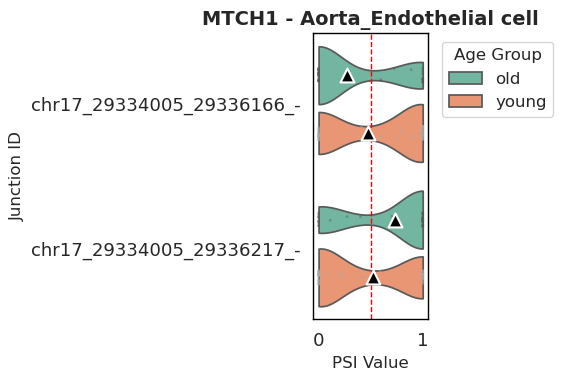

                cell_type                junction_id  \
0  Aorta_Endothelial cell  chr17_29334005_29336166_-   
1  Aorta_Endothelial cell  chr17_29334005_29336217_-   

                       event_id gene_name  n_cells_young  n_cells_old  \
0  ENSMUSG00000024012.18_atse_5     MTCH1             60           42   
1  ENSMUSG00000024012.18_atse_5     MTCH1             60           42   

   psi_mean_young  psi_mean_old  delta_psi_mean  psi_median_young  \
0        0.570719      0.321676       -0.249044          0.860526   
1        0.429281      0.678324        0.249044          0.139474   

   psi_median_old  delta_psi_median  pb_young    pb_old  delta_pb  
0             0.0         -0.860526  0.478534  0.269278 -0.209256  
1             1.0          0.860526  0.521466  0.730722  0.209256  
                cell_type                      event_id  n_junctions  \
0  Aorta_Endothelial cell  ENSMUSG00000024012.18_atse_5            2   

   mean_delta_mean  median_delta_median  mean_abs_delt

In [14]:
junction ="chr17_29334005_29336217_-"
print(junction)
cell_type = "Aorta_Endothelial cell"
result_df  = extract_junction_data(splice_adata, junction, cell_type)
j_df, atse_df = delta_psi_from_result_df(result_df)
plot_junction_usage_by_age(result_df)
print(j_df)
print(atse_df)


In [15]:
import sys 
# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

gtf_file = "/gpfs/commons/groups/knowles_lab/Megan/encode_pacbio/2025_mouse_longread/2025_mouse_collapse_GRCm38/all_samples_sp_collapse_all_chr_full.gtf"
db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/genomes/lr_GRCm38.db"
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")

# Load the database
db_mouse = gffutils.FeatureDB(db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


In [16]:
atse_df

,event_id,gene_id,gene_name,gene_types,num_junctions,event_type,chromosome,strand,atse_start,atse_end,...,three_prime_usage,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime
0,ENSMUSG00000033845.13_atse_1,ENSMUSG00000033845.13,NaN,NaN,3,complex,chr1,-,4782733,4785572,...,0.9996,0.9996,0.9830,2067357,2102158,GT-AG,GT,AG,1.0,0.0
1,ENSMUSG00000033845.13_atse_1,ENSMUSG00000033845.13,NaN,NaN,3,complex,chr1,-,4782733,4785572,...,0.0162,0.0162,0.0203,2102158,1681184,GT-AG,GT,AG,1.0,0.0
2,ENSMUSG00000033845.13_atse_1,ENSMUSG00000033845.13,NaN,NaN,3,complex,chr1,-,4782733,4785572,...,0.9777,0.9777,0.9985,1681184,1646228,GT-AG,GT,AG,1.0,0.0
3,ENSMUSG00000033845.13_atse_2,ENSMUSG00000033845.13,NaN,NaN,2,alternative_3_prime,chr1,-,4777648,4782567,...,0.0191,0.0191,1.0000,1985489,37835,GT-AG,GT,AG,1.0,0.0
4,ENSMUSG00000033845.13_atse_2,ENSMUSG00000033845.13,NaN,NaN,2,alternative_3_prime,chr1,-,4777648,4782567,...,0.9741,0.9741,0.9935,1985489,1946865,GT-AG,GT,AG,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113990,ENSMUSG00000038729.24_atse_1,ENSMUSG00000038729.24,NaN,NaN,3,alternative_3_prime,chr4,+,57845306,57850550,...,1.0000,0.4870,1.0000,922,449,GT-AG,GT,AG,0.0,NaN
113991,chr11:110997000_atse_1,chr11:110997000,NaN,NaN,2,alternative_5_prime,chr11,+,110968095,111019586,...,0.2769,1.0000,0.2769,185,668,GT-AG,GT,AG,NaN,1.0
113992,chr11:110997000_atse_1,chr11:110997000,NaN,NaN,2,alternative_5_prime,chr11,+,110968095,111019586,...,1.0000,0.7231,1.0000,668,483,GT-AG,GT,AG,NaN,1.0
113993,chr14:55575000_atse_1,chr14:55575000,NaN,NaN,2,alternative_5_prime,chr14,+,55226749,55575736,...,1.0000,0.5000,1.0000,1002,501,GT-AG,GT,AG,NaN,-85.0


Unique transcripts: ['ENSMUST00000095427.11', 'ENSMUST00000118366.8', 'ENSMUST00000234507.1', 'ENSMUST00000235088.1']
Unique transcripts to remove: ['s09ecc0c7eea61ed5:eb9fc45f9aba2c261', 's0afd2f13b485400a:ef5fa0581e47eb114', 's0e8dd15c7c6cb0c2:e0f4d147f36471977', 's0e8dd15c7c6cb0c2:e1c5c633268823b21', 's0f441aa7345a79c5:ef4887f2808965a22', 's0fdc8e4822e854b7:e2e7e926204970628', 's0fde7c9f254755b4:ef5fa0581e47eb114', 's12eb36baf3aa2b04:e2c52a02ba4b1874e', 's12eb36baf3aa2b04:e37f806c7f57e5199', 's12eb36baf3aa2b04:e6b024789df525659', 's12eb36baf3aa2b04:eb19444df74288b4d', 's12eb36baf3aa2b04:ecdf340a60f7ac5aa', 's161bc18aa3f5956f:ef5fa0581e47eb114', 's1c8e18250698afac:ef5fa0581e47eb114', 's1f0c3e8823ef7ca1:edc872739d88eb3c6', 's2ba96cdde3d2d767:e72786b2ac6a59be0', 's2ce641cd17dcf1e0:ef5fa0581e47eb114', 's346cbcc2d899443f:ef7dc32b2638ba685', 's37bc9d9ab9c6e478:ef5fa0581e47eb114', 's3c4e8309b20829c6:ef5fa0581e47eb114', 's3f1edcb1bdea8ca5:e1c5c633268823b21', 's45b07301949893b9:edc872739d88e

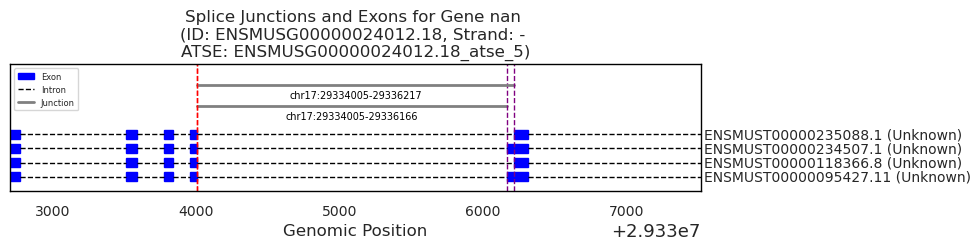

ATSE visualization saved: mouse_ENSMUSG00000024012.18_atse_5.pdf


{'junctions':                            event_id                gene_id  gene_name  \
 13034  ENSMUSG00000024012.18_atse_5  ENSMUSG00000024012.18        NaN   
 13035  ENSMUSG00000024012.18_atse_5  ENSMUSG00000024012.18        NaN   
 
        gene_types  num_junctions           event_type chromosome strand  \
 13034         NaN              2  alternative_5_prime      chr17      -   
 13035         NaN              2  alternative_5_prime      chr17      -   
 
        atse_start  atse_end  ...  acceptor_usage  donor_total_reads  \
 13034    29334005  29336217  ...          0.9996            5291913   
 13035    29334005  29336217  ...          0.4943            2616258   
 
        acceptor_total_reads  splice_motif  donor_seq  acceptor_seq  \
 13034               2674160         GT-AG         GT            AG   
 13035               5291913         GT-AG         GT            AG   
 
       position_off_5_prime position_off_3_prime usage_ratio  \
 13034                  1.0         

In [17]:
mouse_event = "ENSMUSG00000024012.18_atse_5"
# need to fix by adding back columns to atse_df 
visualize_atse_event(mouse_event, atse_df, db_mouse,
                 species="mouse", base_width=10, 
                       trans_height=0.4, 
                  padding=300, show_junc_lines=True)

In [18]:
!pwd

/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation


In [19]:
# load all ATSEs for coordination analysis 
all_juncs = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/FIGURES/FIGURE1/figure1_20251019/junction_df_all_20251020.csv"
all_atses = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/FIGURES/FIGURE1/figure1_20251019/atse_df_all_20251020.csv"
all_juncs_df = pd.read_csv(all_juncs)
all_juncs_df.head()

,cell_type,junction_id,event_id,gene_name,n_cells_young,n_cells_old,psi_mean_young,psi_mean_old,delta_psi_mean,psi_median_young,psi_median_old,delta_psi_median,pb_young,pb_old,delta_pb
0,GAT_Other immune cell,chr10_100016035_100051845_+,ENSMUSG00000019966.18_atse_1,KITL,19.0,4.0,1.000000,1.000000,0.000000,1.0,1.000000,0.000000,1.000000,1.000000,0.000000
1,GAT_Other immune cell,chr10_100016155_100051845_+,ENSMUSG00000019966.18_atse_1,KITL,19.0,4.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2,GAT_Other immune cell,chr10_100080130_100080856_+,ENSMUSG00000019966.18_atse_2,KITL,19.0,4.0,0.078098,0.477704,0.399606,0.0,0.455408,0.455408,0.030948,0.283019,0.252071
3,GAT_Other immune cell,chr10_100080130_100087346_+,ENSMUSG00000019966.18_atse_2,KITL,19.0,4.0,0.894737,0.250000,-0.644737,1.0,0.000000,-1.000000,0.938104,0.452830,-0.485274
4,GAT_Other immune cell,chr10_100080940_100087346_+,ENSMUSG00000019966.18_atse_2,KITL,19.0,4.0,0.027165,0.272296,0.245131,0.0,0.205882,0.205882,0.030948,0.264151,0.233203


In [20]:
all_atses_df = pd.read_csv(all_atses)
all_atses_df.head()

,cell_type,event_id,n_junctions,mean_delta_mean,median_delta_median,mean_abs_delta,std_delta,sign_concordance,mean_delta_pb,median_delta_pb,opposite_sign_pair
0,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000019966.18_atse_1,2,-1.387779e-17,0.000000,0.004092,0.005787,0.500000,1.040834e-17,1.040834e-17,1.0
1,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000019966.18_atse_2,3,2.775558e-17,-0.006706,0.022149,0.029925,0.666667,9.251859e-18,1.517588e-02,NaN
2,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000036676.14_atse_2,2,-2.775558e-17,0.000000,0.142857,0.202031,0.500000,-1.387779e-17,-1.387779e-17,1.0
3,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000036676.14_atse_1,4,0.000000e+00,0.000000,0.107143,0.163684,0.750000,-2.775558e-17,7.836134e-02,NaN
4,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000019971.10_atse_1,3,9.251859e-18,0.000000,0.047619,0.071429,0.500000,-1.850372e-17,0.000000e+00,NaN


In [21]:
twos = splice_adata.var[splice_adata.var["num_junctions"] == 2]
twos_events = twos["event_id"].unique()
twos_events

['ENSMUSG00000019966.18_atse_1', 'ENSMUSG00000036676.14_atse_2', 'ENSMUSG00000044921.5_atse_1', 'ENSMUSG00000019832.5_atse_1', 'ENSMUSG00000019897.8_atse_1', ..., 'ENSMUSG00000031217.8_atse_1', 'ENSMUSG00000034403.16_atse_2', 'ENSMUSG00000069049.11_atse_3', 'ENSMUSG00000069045.11_atse_3', 'ENSMUSG00000069045.11_atse_1']
Length: 6479
Categories (15930, object): ['ENSMUSG00000000001.4_atse_1', 'ENSMUSG00000000028.15_atse_2', 'ENSMUSG00000000085.16_atse_2', 'ENSMUSG00000000085.16_atse_3', ..., 'ENSMUSG00000116564.1_atse_1', 'ENSMUSG00000117679.1_atse_1', 'ENSMUSG00000117679.1_atse_2', 'ENSMUSG00000117679.1_atse_3']

In [22]:
# keep only rows where n_cells_young and n_cells_old is greater than 10     
all_juncs_df = all_juncs_df[all_juncs_df["n_cells_young"] > 20]
all_juncs_df = all_juncs_df[all_juncs_df["n_cells_old"] > 20]
all_juncs_df.sort_values(by="delta_psi_mean", ascending=False)

,cell_type,junction_id,event_id,gene_name,n_cells_young,n_cells_old,psi_mean_young,psi_mean_old,delta_psi_mean,psi_median_young,psi_median_old,delta_psi_median,pb_young,pb_old,delta_pb
343399,Diaphragm_Mesenchymal stem cell,chr9_7870691_7872822_-,ENSMUSG00000032000.17_atse_1,BIRC3,54.0,26.0,0.123677,0.807692,0.684015,0.000000,1.000000,1.000000,0.089990,0.799095,0.709105
899623,BAT_B cell,chr2_35266903_35283904_+,ENSMUSG00000026879.14_atse_1,GSN,54.0,21.0,0.392931,1.000000,0.607069,0.000000,1.000000,1.000000,0.857494,1.000000,0.142506
296932,Heart_Fibroblast,chrX_136832109_136833267_+,ENSMUSG00000031425.15_atse_7,PLP1,70.0,31.0,0.255051,0.809583,0.554532,0.000000,1.000000,1.000000,0.873506,0.990796,0.117290
438420,Brain_Non-Myeloid_Other neuron,chrX_166384000_166385390_+,ENSMUSG00000031342.17_atse_3,GPM6B,87.0,101.0,0.431928,0.934312,0.502384,0.116505,1.000000,0.883495,0.863669,0.994052,0.130383
199688,Heart_Cardiac stromal cell,chr11_116080344_116080545_-,ENSMUSG00000034341.17_atse_4,WBP2,118.0,126.0,0.113649,0.615374,0.501726,0.085145,0.594289,0.509144,0.108251,0.604667,0.496416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442132,Heart_Cardiomyocyte,chr11_107212658_107226230_-,ENSMUSG00000040430.18_atse_2,PITPNC1,30.0,22.0,0.805556,0.280992,-0.524564,1.000000,0.000000,-1.000000,0.647222,0.096774,-0.550448
80040,Heart_Monocyte,chr4_136892889_136932855_-,ENSMUSG00000036896.5_atse_1,C1QC,24.0,55.0,0.916667,0.386786,-0.529880,1.000000,0.000000,-1.000000,0.781250,0.121212,-0.660038
343392,Diaphragm_Mesenchymal stem cell,chr9_7861407_7872822_-,ENSMUSG00000032000.17_atse_1,BIRC3,54.0,26.0,0.702514,0.153846,-0.548668,1.000000,0.000000,-1.000000,0.586451,0.030173,-0.556277
296933,Heart_Fibroblast,chrX_136832214_136833267_+,ENSMUSG00000031425.15_atse_7,PLP1,70.0,31.0,0.744949,0.190417,-0.554532,1.000000,0.000000,-1.000000,0.126494,0.009204,-0.117290


In [23]:
twos_all_juncs = all_juncs_df[all_juncs_df["event_id"].isin(twos_events)]
twos_all_juncs.head()
twos_all_juncs.sort_values(by="delta_psi_mean", ascending=False)

,cell_type,junction_id,event_id,gene_name,n_cells_young,n_cells_old,psi_mean_young,psi_mean_old,delta_psi_mean,psi_median_young,psi_median_old,delta_psi_median,pb_young,pb_old,delta_pb
296932,Heart_Fibroblast,chrX_136832109_136833267_+,ENSMUSG00000031425.15_atse_7,PLP1,70.0,31.0,0.255051,0.809583,0.554532,0.00,1.000000,1.000000,0.873506,0.990796,0.117290
449878,Heart_Cardiomyocyte,chr14_32165822_32170747_+,ENSMUSG00000056234.15_atse_1,NCOA4,30.0,23.0,0.066667,0.536715,0.470048,0.00,0.844444,0.844444,0.092643,0.795259,0.702616
942001,GAT_Mesenchymal stem cell,chr1_38269761_38304677_-,ENSMUSG00000037138.18_atse_4,AFF3,41.0,31.0,0.266417,0.731700,0.465283,0.00,1.000000,1.000000,0.325416,0.837143,0.511727
613204,Diaphragm_Skeletal muscle cell,chr3_116123793_116124382_-,ENSMUSG00000027962.14_atse_2,VCAM1,189.0,75.0,0.426813,0.870352,0.443539,0.33,1.000000,0.670000,0.479632,0.950127,0.470495
462717,Heart_Cardiomyocyte,chr1_93725316_93749846_-,ENSMUSG00000026279.14_atse_1,THAP4,40.0,24.0,0.237439,0.605460,0.368021,0.00,1.000000,1.000000,0.261421,0.814262,0.552841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462716,Heart_Cardiomyocyte,chr1_93725316_93731856_-,ENSMUSG00000026279.14_atse_1,THAP4,40.0,24.0,0.762561,0.394540,-0.368021,1.00,0.000000,-1.000000,0.738579,0.185738,-0.552841
613203,Diaphragm_Skeletal muscle cell,chr3_116121073_116124382_-,ENSMUSG00000027962.14_atse_2,VCAM1,189.0,75.0,0.573187,0.129648,-0.443539,0.67,0.000000,-0.670000,0.520368,0.049873,-0.470495
942002,GAT_Mesenchymal stem cell,chr1_38269761_38320111_-,ENSMUSG00000037138.18_atse_4,AFF3,41.0,31.0,0.733583,0.268300,-0.465283,1.00,0.000000,-1.000000,0.674584,0.162857,-0.511727
449877,Heart_Cardiomyocyte,chr14_32160010_32170747_+,ENSMUSG00000056234.15_atse_1,NCOA4,30.0,23.0,0.933333,0.463285,-0.470048,1.00,0.155556,-0.844444,0.907357,0.204741,-0.702616


In [24]:
twos_all_juncs[twos_all_juncs["event_id"] == "ENSMUSG00000017754.13_atse_1"]

,cell_type,junction_id,event_id,gene_name,n_cells_young,n_cells_old,psi_mean_young,psi_mean_old,delta_psi_mean,psi_median_young,psi_median_old,delta_psi_median,pb_young,pb_old,delta_pb
24668,GAT_Other immune cell,chr2_164856997_164857544_-,ENSMUSG00000017754.13_atse_1,PLTP,214.0,105.0,0.036176,0.031695,-0.004481,0.0,0.0,0.0,0.046749,0.039158,-0.007591
24669,GAT_Other immune cell,chr2_164856997_164857583_-,ENSMUSG00000017754.13_atse_1,PLTP,214.0,105.0,0.963824,0.968305,0.004481,1.0,1.0,0.0,0.953251,0.960842,0.007591
73953,Heart_Monocyte,chr2_164856997_164857544_-,ENSMUSG00000017754.13_atse_1,PLTP,267.0,340.0,0.033250,0.026137,-0.007113,0.0,0.0,0.0,0.040648,0.040241,-0.000407
73954,Heart_Monocyte,chr2_164856997_164857583_-,ENSMUSG00000017754.13_atse_1,PLTP,267.0,340.0,0.966750,0.973863,0.007113,1.0,1.0,0.0,0.959352,0.959759,0.000407
171687,Brain_Non-Myeloid_Endothelial cell,chr2_164856997_164857544_-,ENSMUSG00000017754.13_atse_1,PLTP,510.0,880.0,0.037639,0.028536,-0.009103,0.0,0.0,0.0,0.036503,0.031882,-0.004621
171688,Brain_Non-Myeloid_Endothelial cell,chr2_164856997_164857583_-,ENSMUSG00000017754.13_atse_1,PLTP,510.0,880.0,0.962361,0.971464,0.009103,1.0,1.0,0.0,0.963497,0.968118,0.004621
221660,Heart_Cardiac stromal cell,chr2_164856997_164857544_-,ENSMUSG00000017754.13_atse_1,PLTP,28.0,58.0,0.035714,0.016072,-0.019642,0.0,0.0,0.0,0.027473,0.035536,0.008063
221661,Heart_Cardiac stromal cell,chr2_164856997_164857583_-,ENSMUSG00000017754.13_atse_1,PLTP,28.0,58.0,0.964286,0.983928,0.019642,1.0,1.0,0.0,0.972527,0.964464,-0.008063
272498,Heart_Fibroblast,chr2_164856997_164857544_-,ENSMUSG00000017754.13_atse_1,PLTP,590.0,495.0,0.026771,0.024035,-0.002737,0.0,0.0,0.0,0.032654,0.022691,-0.009963
272499,Heart_Fibroblast,chr2_164856997_164857583_-,ENSMUSG00000017754.13_atse_1,PLTP,590.0,495.0,0.973229,0.975965,0.002737,1.0,1.0,0.0,0.967346,0.977309,0.009963


In [25]:
# subset twos_all_juncs to only those where absolute delta_psi_mean is greater than 0.05 
twos_all_juncs = twos_all_juncs[twos_all_juncs["delta_psi_mean"].abs() > 0.05]
twos_all_juncs.head()

,cell_type,junction_id,event_id,gene_name,n_cells_young,n_cells_old,psi_mean_young,psi_mean_old,delta_psi_mean,psi_median_young,psi_median_old,delta_psi_median,pb_young,pb_old,delta_pb
145,GAT_Other immune cell,chr10_117356124_117358992_-,ENSMUSG00000055531.12_atse_3,CPSF6,55.0,39.0,0.765121,0.624205,-0.140916,1.0,1.0,0.0,0.776794,0.804506,0.027712
146,GAT_Other immune cell,chr10_117356127_117358992_-,ENSMUSG00000055531.12_atse_3,CPSF6,55.0,39.0,0.234879,0.375795,0.140916,0.0,0.0,0.0,0.223206,0.195494,-0.027712
430,GAT_Other immune cell,chr10_128368153_128368518_-,ENSMUSG00000039914.6_atse_1,COQ10A,36.0,28.0,0.055556,0.107143,0.051587,0.0,0.0,0.0,0.020408,0.121681,0.101273
431,GAT_Other immune cell,chr10_128368153_128368697_-,ENSMUSG00000039914.6_atse_1,COQ10A,36.0,28.0,0.944444,0.892857,-0.051587,1.0,1.0,0.0,0.979592,0.878319,-0.101273
728,GAT_Other immune cell,chr10_26872764_26874097_+,ENSMUSG00000039031.16_atse_2,ARHGAP18,66.0,21.0,0.000000,0.095238,0.095238,0.0,0.0,0.0,0.000000,0.092873,0.092873


In [26]:
# Group by cell_type and event_id, then calculate coordination metrics
coordination = twos_all_juncs.groupby(['cell_type', 'event_id']).agg({
    'delta_psi_mean': lambda x: x.std() if len(x) > 1 else 0,  # Spread of changes
    'junction_id': 'count'  # Number of junctions
}).rename(columns={'junction_id': 'n_junctions', 'delta_psi_mean': 'delta_psi_std'})

# Add coordination score: high std = strong coordination (opposite directions)
coordination['coordination_strength'] = coordination['delta_psi_std']

# Filter for events with multiple junctions (where coordination matters)
coordination = coordination[coordination['n_junctions'] > 1]

coordination.sort_values('coordination_strength', ascending=False).head(10)

,,delta_psi_std,n_junctions,coordination_strength
cell_type,event_id,,,
Heart_Fibroblast,ENSMUSG00000031425.15_atse_7,0.784227,2,0.784227
Heart_Cardiomyocyte,ENSMUSG00000056234.15_atse_1,0.664749,2,0.664749
GAT_Mesenchymal stem cell,ENSMUSG00000037138.18_atse_4,0.658010,2,0.658010
Diaphragm_Skeletal muscle cell,ENSMUSG00000027962.14_atse_2,0.627259,2,0.627259
Heart_Cardiomyocyte,ENSMUSG00000026279.14_atse_1,0.520460,2,0.520460
Heart_Endothelial cell,ENSMUSG00000054263.12_atse_2,0.510553,2,0.510553
Heart_Monocyte,ENSMUSG00000028207.18_atse_6,0.506795,2,0.506795
GAT_Other immune cell,ENSMUSG00000066406.16_atse_5,0.505719,2,0.505719
Bladder_Urogenital epithelial cell,ENSMUSG00000039671.18_atse_5,0.503216,2,0.503216


In [27]:
coordination.sort_values('coordination_strength', ascending=True).head(10)

,,delta_psi_std,n_junctions,coordination_strength
cell_type,event_id,,,
BAT_Endothelial cell,ENSMUSG00000017754.13_atse_1,0.070719,2,0.070719
BAT_B cell,ENSMUSG00000011960.12_atse_1,0.070762,2,0.070762
Bladder_Bladder epithelial cell,ENSMUSG00000035960.14_atse_2,0.070786,2,0.070786
GAT_Mesenchymal stem cell,ENSMUSG00000001870.16_atse_3,0.070790,2,0.070790
Bladder_Urogenital epithelial cell,ENSMUSG00000027463.14_atse_1,0.070839,2,0.070839
Large_Intestine_Intestinal epithelial cell,ENSMUSG00000070003.7_atse_3,0.070844,2,0.070844
Large_Intestine_Epithelial stem cell,ENSMUSG00000026956.15_atse_2,0.070849,2,0.070849
Heart_Monocyte,ENSMUSG00000021096.11_atse_2,0.070851,2,0.070851
Large_Intestine_Intestinal epithelial cell,ENSMUSG00000046711.16_atse_2,0.070857,2,0.070857


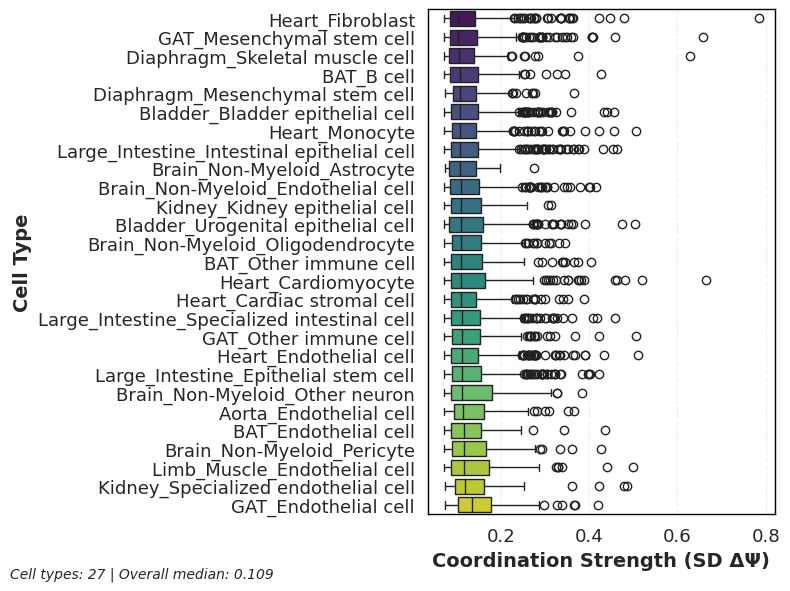


Summary Statistics:
Number of cell types: 27
Overall median coordination strength: 0.1088

Top 5 cell types with highest median coordination:
1. BAT_Endothelial cell: 0.1150
2. Brain_Non-Myeloid_Pericyte: 0.1164
3. Limb_Muscle_Endothelial cell: 0.1172
4. Kidney_Specialized endothelial cell: 0.1183
5. GAT_Endothelial cell: 0.1351

Bottom 5 cell types with lowest median coordination:
1. Heart_Fibroblast: 0.1025
2. GAT_Mesenchymal stem cell: 0.1035
3. Diaphragm_Skeletal muscle cell: 0.1045
4. BAT_B cell: 0.1060
5. Diaphragm_Mesenchymal stem cell: 0.1061


In [28]:
# Calculate median coordination strength by cell type for ordering
median_coordination = coordination.groupby('cell_type')['coordination_strength'].median().sort_values()
cell_type_order = median_coordination.index.tolist()

# Create improved plot with better styling
plt.figure(figsize=(8, 6))

# Create boxplot with ordered cell types
sns.boxplot(y="cell_type", x="coordination_strength", data=coordination, 
           order=cell_type_order, palette="viridis")

# Improve labels and formatting
plt.xlabel('Coordination Strength (SD ΔΨ)', fontsize=14, fontweight='bold')
plt.ylabel('Cell Type', fontsize=14, fontweight='bold')

# Add grid for better readability
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Add summary statistics
n_cell_types = len(cell_type_order)
median_overall = coordination['coordination_strength'].median()
plt.figtext(0.02, 0.02, f'Cell types: {n_cell_types} | Overall median: {median_overall:.3f}', 
           fontsize=10, style='italic')

plt.show()

# Print summary statistics
print(f"\nSummary Statistics:")
print(f"Number of cell types: {n_cell_types}")
print(f"Overall median coordination strength: {median_overall:.4f}")
print(f"\nTop 5 cell types with highest median coordination:")
for i, (cell_type, median_val) in enumerate(median_coordination.tail().items(), 1):
    print(f"{i}. {cell_type}: {median_val:.4f}")
print(f"\nBottom 5 cell types with lowest median coordination:")
for i, (cell_type, median_val) in enumerate(median_coordination.head().items(), 1):
    print(f"{i}. {cell_type}: {median_val:.4f}")

chr2_164856997_164857544_-



PLTP - BAT_Endothelial cell

Sample counts per junction and age group:
cell_age_group              old  young
junction_id                           
chr2_164856997_164857544_-   56     52
chr2_164856997_164857583_-   56     52


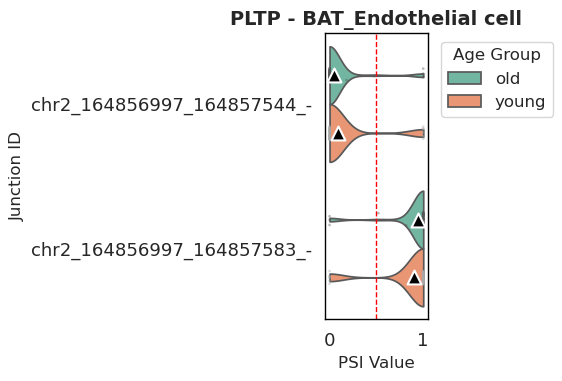

              cell_type                 junction_id  \
0  BAT_Endothelial cell  chr2_164856997_164857544_-   
1  BAT_Endothelial cell  chr2_164856997_164857583_-   

                       event_id gene_name  n_cells_young  n_cells_old  \
0  ENSMUSG00000017754.13_atse_1      PLTP             52           56   
1  ENSMUSG00000017754.13_atse_1      PLTP             52           56   

   psi_mean_young  psi_mean_old  delta_psi_mean  psi_median_young  \
0        0.115385      0.065379       -0.050006               0.0   
1        0.884615      0.934621        0.050006               1.0   

   psi_median_old  delta_psi_median  pb_young    pb_old  delta_pb  
0             0.0               0.0  0.094269  0.051758 -0.042511  
1             1.0               0.0  0.905731  0.948242  0.042511  
              cell_type                      event_id  n_junctions  \
0  BAT_Endothelial cell  ENSMUSG00000017754.13_atse_1            2   

   mean_delta_mean  median_delta_median  mean_abs_delta  std_

In [29]:
junction ="chr2_164856997_164857544_-"
print(junction)
cell_type = "BAT_Endothelial cell"
result_df  = extract_junction_data(splice_adata, junction, cell_type)
j_df, atse_df = delta_psi_from_result_df(result_df)
plot_junction_usage_by_age(result_df)
print(j_df)
print(atse_df)

In [30]:
cell_type = "Heart_Fibroblast"
atse = "ENSMUSG00000031425.15_atse_7" 
twos_all_juncs[(twos_all_juncs["event_id"] == atse) & (twos_all_juncs["cell_type"] == cell_type)].head()

,cell_type,junction_id,event_id,gene_name,n_cells_young,n_cells_old,psi_mean_young,psi_mean_old,delta_psi_mean,psi_median_young,psi_median_old,delta_psi_median,pb_young,pb_old,delta_pb
296932,Heart_Fibroblast,chrX_136832109_136833267_+,ENSMUSG00000031425.15_atse_7,PLP1,70.0,31.0,0.255051,0.809583,0.554532,0.0,1.0,1.0,0.873506,0.990796,0.11729
296933,Heart_Fibroblast,chrX_136832214_136833267_+,ENSMUSG00000031425.15_atse_7,PLP1,70.0,31.0,0.744949,0.190417,-0.554532,1.0,0.0,-1.0,0.126494,0.009204,-0.11729


chrX_136832109_136833267_+

PLP1 - Heart_Fibroblast

Sample counts per junction and age group:
cell_age_group              old  young
junction_id                           
chrX_136832109_136833267_+   31     70
chrX_136832214_136833267_+   31     70


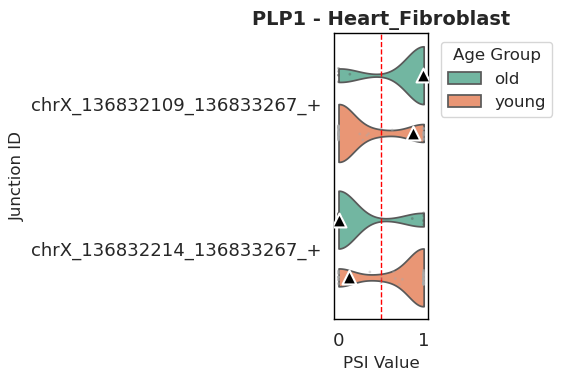

          cell_type                 junction_id                      event_id  \
0  Heart_Fibroblast  chrX_136832109_136833267_+  ENSMUSG00000031425.15_atse_7   
1  Heart_Fibroblast  chrX_136832214_136833267_+  ENSMUSG00000031425.15_atse_7   

  gene_name  n_cells_young  n_cells_old  psi_mean_young  psi_mean_old  \
0      PLP1             70           31        0.255051      0.809583   
1      PLP1             70           31        0.744949      0.190417   

   delta_psi_mean  psi_median_young  psi_median_old  delta_psi_median  \
0        0.554532               0.0             1.0               1.0   
1       -0.554532               1.0             0.0              -1.0   

   pb_young    pb_old  delta_pb  
0  0.873506  0.990796   0.11729  
1  0.126494  0.009204  -0.11729  
          cell_type                      event_id  n_junctions  \
0  Heart_Fibroblast  ENSMUSG00000031425.15_atse_7            2   

   mean_delta_mean  median_delta_median  mean_abs_delta  std_delta  \
0    -5.551

In [31]:
junction ="chrX_136832109_136833267_+"
print(junction)
cell_type = "Heart_Fibroblast"
result_df  = extract_junction_data(splice_adata, junction, cell_type)
j_df, atse_df = delta_psi_from_result_df(result_df)
plot_junction_usage_by_age(result_df)
print(j_df)
print(atse_df)


In [32]:
mouse_event = "ENSMUSG00000031425.15_atse_7"
# need to fix by adding back columns to atse_df 
visualize_atse_event(mouse_event, atse_df, db_mouse,
                 species="mouse", base_width=6, 
                       trans_height=0.8, 
                  padding=100, show_junc_lines=True)

Error processing ATSE event ENSMUSG00000031425.15_atse_7: 'junction_id'


Traceback (most recent call last):
  File "/gpfs/commons/home/kisaev/.local/lib/python3.10/site-packages/pandas/core/indexes/base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7081, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7089, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'junction_id'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py", line 94, in visualize_atse_event
    splice_junctions = convert_junction_ids(juncs)
  File "/gpfs/commons/home/kisaev/LeafletFA-utils/leafletfa_utils/atseviz/main.py", line 51, in conve

In [33]:
splice_adata

AnnData object with n_obs × n_vars = 85692 × 52290
    obs: 'cell_id_index', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'broad_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'age_group', 'tissue_celltype'
    var: 'level_0', 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'n_cells_detected', 'confidence', 'aging_gene', 'aging_lifespan_effect', 'aging_longevity_influence'
    obsm: 'X_library_size'
    layers: 'cell_by_cluster_matrix', 'cell_by_junction_matrix', 'psi', 'psi_valid'

In [44]:
twos_all_juncs[twos_all_juncs["event_id"] == "ENSMUSG00000055531.12_atse_3"][0:2]

,cell_type,junction_id,event_id,gene_name,n_cells_young,n_cells_old,psi_mean_young,psi_mean_old,delta_psi_mean,psi_median_young,psi_median_old,delta_psi_median,pb_young,pb_old,delta_pb
145,GAT_Other immune cell,chr10_117356124_117358992_-,ENSMUSG00000055531.12_atse_3,CPSF6,55.0,39.0,0.765121,0.624205,-0.140916,1.0,1.0,0.0,0.776794,0.804506,0.027712
146,GAT_Other immune cell,chr10_117356127_117358992_-,ENSMUSG00000055531.12_atse_3,CPSF6,55.0,39.0,0.234879,0.375795,0.140916,0.0,0.0,0.0,0.223206,0.195494,-0.027712


In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Filter splice_adata to junctions in twos_all_juncs
junctions_to_use = twos_all_juncs["junction_id"].unique()
# splice_adata_filt = splice_adata[:, splice_adata.var["junction_id"].isin(junctions_to_use)]

# Get cell types from twos_all_juncs
cell_types_to_use = twos_all_juncs["cell_type"].unique()
splice_adata_filt = splice_adata[splice_adata.obs["tissue_celltype"].isin(cell_types_to_use)]

def calculate_correlations(adata, age_group):
    """Calculate pairwise correlations for a specific age group"""
    adata_age = adata[adata.obs["age_group"] == age_group]
    
    cell_types = adata_age.obs["tissue_celltype"].values
    unique_celltypes = np.unique(cell_types)
    
    psi_matrix = adata_age.layers["psi"]
    psi_by_celltype = []
    
    for ct in unique_celltypes:
        mask = cell_types == ct
        ct_mean = np.array(psi_matrix[mask, :].mean(axis=0)).flatten()
        psi_by_celltype.append(ct_mean)
    
    psi_by_celltype = pd.DataFrame(
        psi_by_celltype,
        index=unique_celltypes,
        columns=adata_age.var["junction_id"].values
    )
    
    return psi_by_celltype.T.corr()

# Calculate correlations for young and old
corr_young = calculate_correlations(splice_adata, "young")
corr_old = calculate_correlations(splice_adata, "old")

# Calculate delta (change in correlation from young to old)
delta_corr = corr_old - corr_young

In [39]:
delta_corr

,Aorta_Endothelial cell,Aorta_Fibroblast,Aorta_Macrophage,Aorta_Other epithelial cell,Aorta_Other immune cell,BAT_B cell,BAT_Endothelial cell,BAT_Mesenchymal stem cell,BAT_Nk cell,BAT_Other epithelial cell,...,Tongue_Skin epithelial cell,Trachea_Endothelial cell,Trachea_Fibroblast,Trachea_Granulocyte,Trachea_Macrophage,Trachea_Respiratory epithelial cell,Trachea_Secretory cell,Trachea_Skin epithelial cell,Trachea_Smooth muscle cell,Trachea_T cell
Aorta_Endothelial cell,0.000000,-0.051891,NaN,0.158808,0.072514,0.018139,0.025672,0.006765,-0.000153,0.241770,...,0.000544,0.035108,0.024807,0.147045,0.028510,0.057080,-0.007339,NaN,-0.017244,0.047506
Aorta_Fibroblast,-0.051891,0.000000,NaN,0.093131,-0.065515,-0.067116,-0.048237,0.005053,-0.031023,0.136507,...,-0.024703,-0.002863,0.036770,0.061083,-0.032035,-0.063228,-0.065924,NaN,0.001593,-0.070741
Aorta_Macrophage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aorta_Other epithelial cell,0.158808,0.093131,NaN,0.000000,0.169370,0.104599,0.107861,0.143724,0.099426,0.340646,...,0.168890,0.174493,0.166317,0.218833,0.175134,0.229014,0.132111,NaN,0.158389,0.194928
Aorta_Other immune cell,0.072514,-0.065515,NaN,0.169370,0.000000,0.083745,0.029773,0.040552,0.020632,0.285649,...,0.020308,0.106125,0.063913,0.213995,0.120519,0.114962,0.001127,NaN,-0.000150,0.147838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Trachea_Respiratory epithelial cell,0.057080,-0.063228,NaN,0.229014,0.114962,0.075210,0.027395,0.018615,0.050850,0.318975,...,-0.022577,0.064210,0.026847,0.175413,0.064974,0.000000,0.000157,NaN,0.026800,0.060672
Trachea_Secretory cell,-0.007339,-0.065924,NaN,0.132111,0.001127,-0.005245,-0.030015,-0.029658,0.014191,0.190238,...,0.026010,0.051962,0.031413,0.125422,0.053571,0.000157,0.000000,NaN,0.048094,0.012754
Trachea_Skin epithelial cell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Trachea_Smooth muscle cell,-0.017244,0.001593,NaN,0.158389,-0.000150,0.034908,-0.022479,-0.016862,0.066937,0.236478,...,0.068848,-0.006967,-0.011871,0.095490,0.052655,0.026800,0.048094,NaN,0.000000,-0.014535


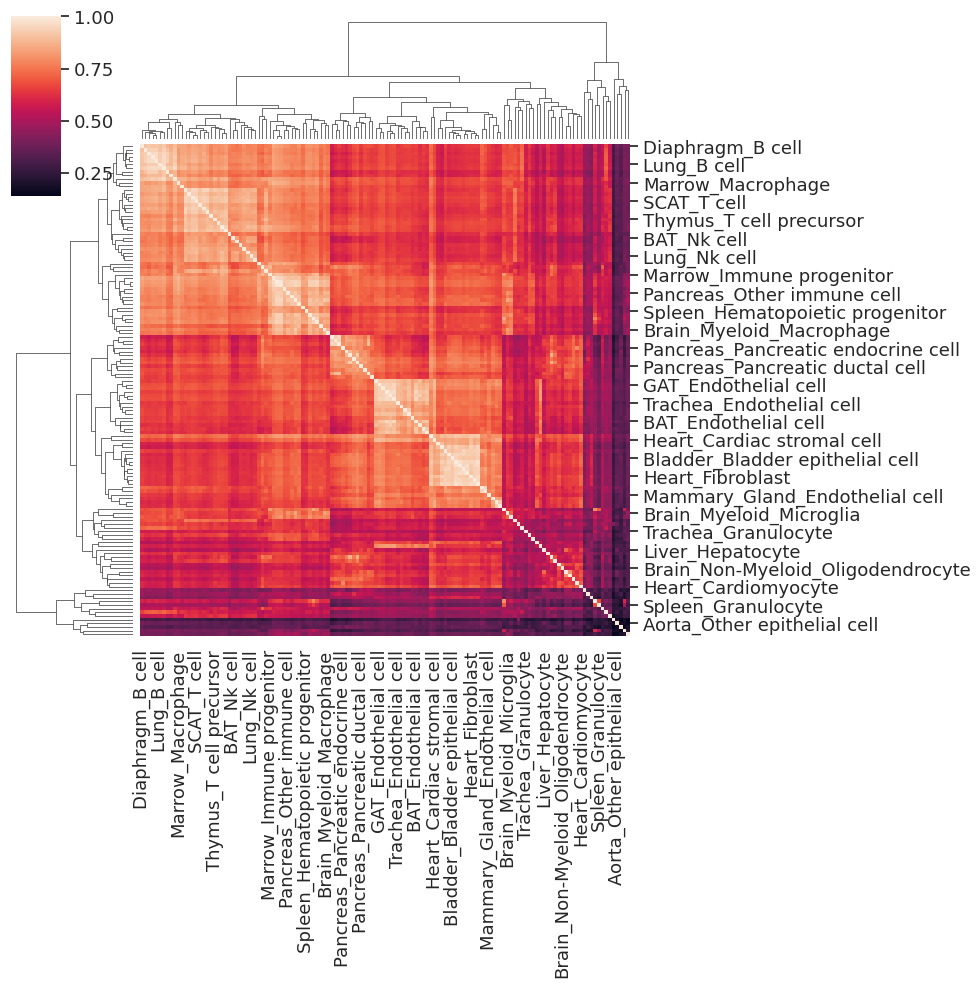

In [36]:
sns.clustermap(corr_young)

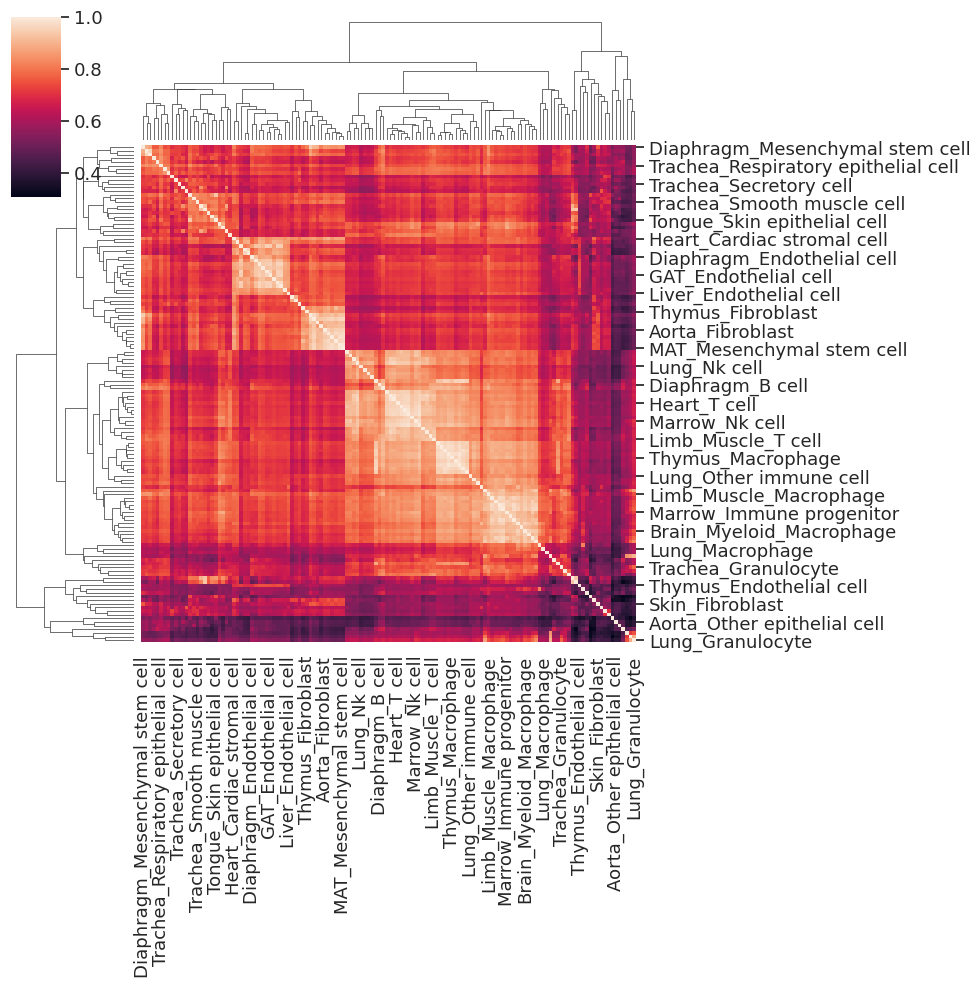

In [37]:
sns.clustermap(corr_old)

SUMMARY: Change in Cell Type PSI Correlations (Old - Young)

Total cell type pairs: 8515

Increased correlation (positive Δ): 7229 (84.9%)
Decreased correlation (negative Δ): 1286 (15.1%)
No change (Δ = 0): 0

Mean Δ correlation: 0.0751
Median Δ correlation: 0.0500
Std Δ correlation: 0.0958

Strong increases (Δ > 0.1): 2297 (27.0%)
Strong decreases (Δ < -0.1): 35 (0.4%)


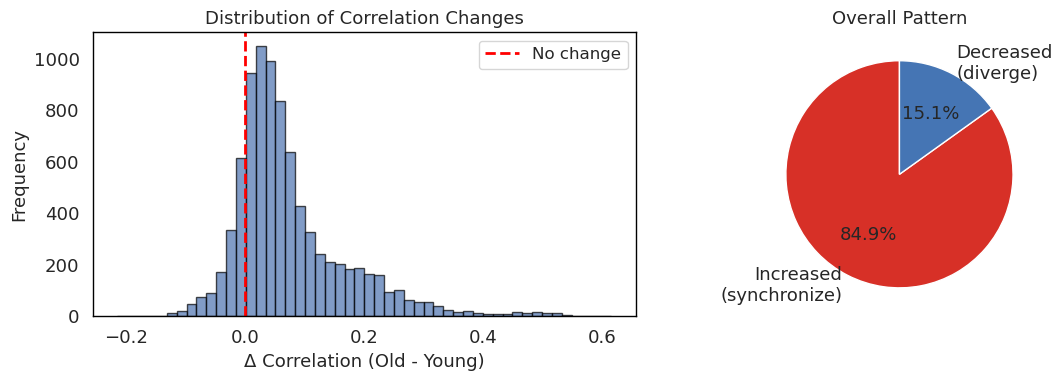

In [38]:
# Get upper triangle (to avoid counting each pair twice)
upper_triangle_mask = np.triu(np.ones_like(delta_corr, dtype=bool), k=1)
delta_values = delta_corr.where(upper_triangle_mask).stack()

# Summary statistics
print("=" * 60)
print("SUMMARY: Change in Cell Type PSI Correlations (Old - Young)")
print("=" * 60)
print(f"\nTotal cell type pairs: {len(delta_values)}")
print(f"\nIncreased correlation (positive Δ): {(delta_values > 0).sum()} ({100 * (delta_values > 0).sum() / len(delta_values):.1f}%)")
print(f"Decreased correlation (negative Δ): {(delta_values < 0).sum()} ({100 * (delta_values < 0).sum() / len(delta_values):.1f}%)")
print(f"No change (Δ = 0): {(delta_values == 0).sum()}")

print(f"\nMean Δ correlation: {delta_values.mean():.4f}")
print(f"Median Δ correlation: {delta_values.median():.4f}")
print(f"Std Δ correlation: {delta_values.std():.4f}")

print(f"\nStrong increases (Δ > 0.1): {(delta_values > 0.1).sum()} ({100 * (delta_values > 0.1).sum() / len(delta_values):.1f}%)")
print(f"Strong decreases (Δ < -0.1): {(delta_values < -0.1).sum()} ({100 * (delta_values < -0.1).sum() / len(delta_values):.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(delta_values, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
axes[0].set_xlabel('Δ Correlation (Old - Young)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Correlation Changes')
axes[0].legend()

# Pie chart
colors = ['#d73027', '#4575b4']
axes[1].pie([
    (delta_values > 0).sum(),
    (delta_values < 0).sum()
], labels=['Increased\n(synchronize)', 'Decreased\n(diverge)'], 
   autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Overall Pattern')

plt.tight_layout()
plt.show()

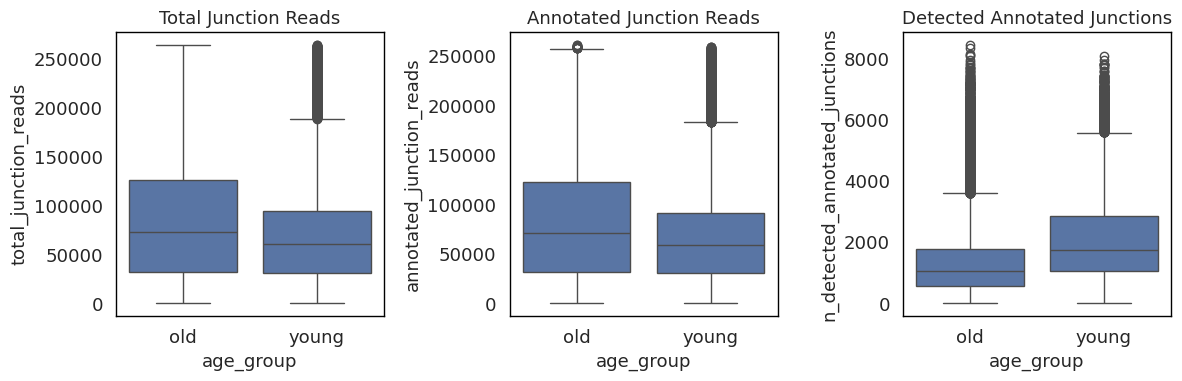

In [ ]:
# make boxplot comparing splice_adata.obs total_junction_reads, annotated_junction_reads, n_detected_annotated_junctions broken down by age_group 
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Boxplot for total_junction_reads
sns.boxplot(x="age_group", y="total_junction_reads", data=splice_adata.obs, ax=axes[0])
axes[0].set_title('Total Junction Reads')

# Boxplot for annotated_junction_reads
sns.boxplot(x="age_group", y="annotated_junction_reads", data=splice_adata.obs, ax=axes[1])
axes[1].set_title('Annotated Junction Reads')

# Boxplot for n_detected_annotated_junctions
sns.boxplot(x="age_group", y="n_detected_annotated_junctions", data=splice_adata.obs, ax=axes[2])
axes[2].set_title('Detected Annotated Junctions')

plt.tight_layout()
plt.show()

In [ ]:
# make boxplot comparing splice_adata.obs total_junction_reads, annotated_junction_reads, n_detected_annotated_junctions broken down by broad_cell_type
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Boxplot for total_junction_reads
sns.boxplot(x="broad_cell_type", y="total_junction_reads", data=splice_adata.obs, ax=axes[0])
axes[0].set_title('Total Junction Reads by Cell Type')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot for annotated_junction_reads
sns.boxplot(x="broad_cell_type", y="annotated_junction_reads", data=splice_adata.obs, ax=axes[1])
axes[1].set_title('Annotated Junction Reads by Cell Type')
axes[1].tick_params(axis='x', rotation=45)

# Boxplot for n_detected_annotated_junctions
sns.boxplot(x="broad_cell_type", y="n_detected_annotated_junctions", data=splice_adata.obs, ax=axes[2])
axes[2].set_title('Detected Annotated Junctions by Cell Type')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
